# KAN Layers vs Standard PyTorch Layers

This notebook compares KAN implementations with standard PyTorch operations:
- Multiplication: `kan_multiply` vs `*`
- Division: `DivisionKAN` vs `/`
- Softmax: `SoftmaxKAN` vs `F.softmax`
- Attention: `AttentionKAN` vs `nn.MultiheadAttention`

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time

from converted_KAN.softmaxkan import (
    kan_multiply, 
    kan_division, 
    kan_reciprocal,
    SoftmaxKAN, 
    DivisionKAN
)
from converted_KAN.attentionkan import (
    kan_matmul,
    AttentionKAN,
    SelfAttentionKAN
)
from converted_KAN import LinearKAN, Conv2dKAN, AvgPool2dKAN, ReLUMaxPool2dKAN
from converted_KAN.ops_counter import count_ops

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Multiplication: `kan_multiply` vs `*`

In [2]:
# Test multiplication
a = torch.randn(100, 100)
b = torch.randn(100, 100)

# Standard multiplication
result_std = a * b

# KAN multiplication: 4ab = (a+b)² - (a-b)²
result_kan = kan_multiply(a, b)

# Compare
diff = (result_std - result_kan).abs()
print(f"Multiplication Comparison:")
print(f"  Max difference: {diff.max().item():.2e}")
print(f"  Mean difference: {diff.mean().item():.2e}")
print(f"  Numerically equal: {torch.allclose(result_std, result_kan, atol=1e-6)}")

Multiplication Comparison:
  Max difference: 9.54e-07
  Mean difference: 4.76e-08
  Numerically equal: True


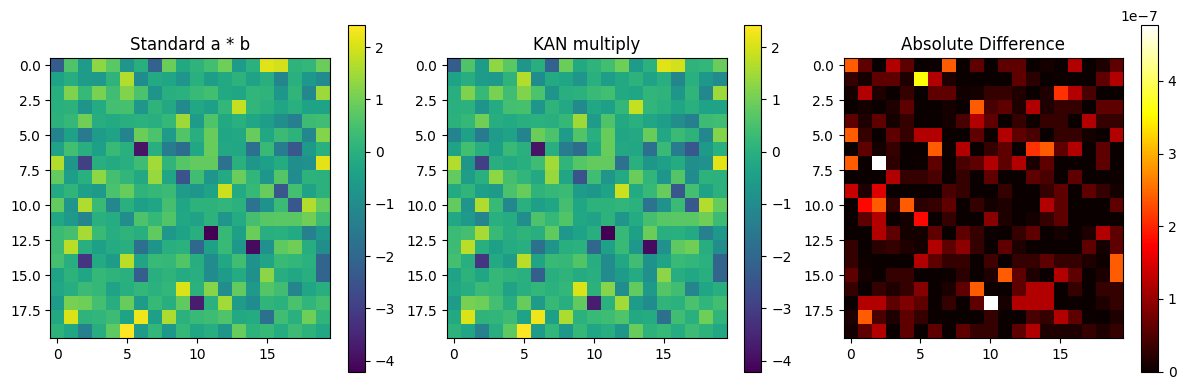

In [3]:
# Visualize multiplication
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(result_std[:20, :20].numpy(), cmap='viridis')
axes[0].set_title('Standard a * b')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(result_kan[:20, :20].numpy(), cmap='viridis')
axes[1].set_title('KAN multiply')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(diff[:20, :20].numpy(), cmap='hot')
axes[2].set_title('Absolute Difference')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## 2. Division: `DivisionKAN` vs `/`

In [4]:
# Test division
a = torch.randn(100, 100)
b = torch.rand(100, 100) + 0.5  # positive values to avoid division issues

# Standard division
result_std = a / b

# KAN division: a/b = a * (1/b)
result_kan = kan_division(a, b)

# Compare
diff = (result_std - result_kan).abs()
print(f"Division Comparison:")
print(f"  Max difference: {diff.max().item():.2e}")
print(f"  Mean difference: {diff.mean().item():.2e}")
print(f"  Numerically equal: {torch.allclose(result_std, result_kan, atol=1e-5)}")

Division Comparison:
  Max difference: 7.15e-07
  Mean difference: 5.79e-08
  Numerically equal: True


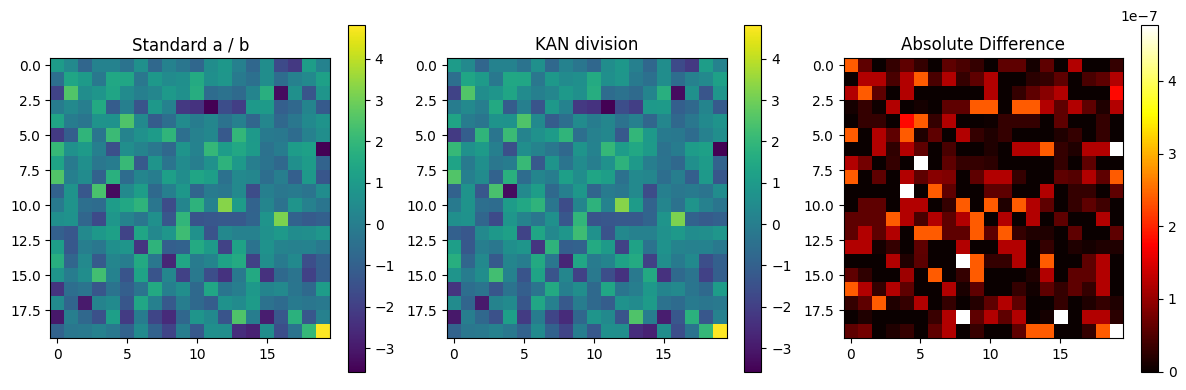

In [5]:
# Visualize division
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(result_std[:20, :20].numpy(), cmap='viridis')
axes[0].set_title('Standard a / b')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(result_kan[:20, :20].numpy(), cmap='viridis')
axes[1].set_title('KAN division')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(diff[:20, :20].numpy(), cmap='hot')
axes[2].set_title('Absolute Difference')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## 3. Softmax: `SoftmaxKAN` vs `F.softmax`

In [6]:
# Test softmax
x = torch.randn(32, 100)  # batch of 32, 100 classes

# Standard softmax
result_std = F.softmax(x, dim=-1)

# KAN softmax
softmax_kan = SoftmaxKAN(dim=-1)
result_kan = softmax_kan(x)

# Compare
diff = (result_std - result_kan).abs()
print(f"Softmax Comparison:")
print(f"  Max difference: {diff.max().item():.2e}")
print(f"  Mean difference: {diff.mean().item():.2e}")
print(f"  Numerically equal: {torch.allclose(result_std, result_kan, atol=1e-6)}")

# Check that outputs sum to 1
print(f"\nSum check (should be 1):")
print(f"  Standard: {result_std.sum(dim=-1).mean().item():.6f}")
print(f"  KAN: {result_kan.sum(dim=-1).mean().item():.6f}")

Softmax Comparison:
  Max difference: 4.47e-08
  Mean difference: 1.32e-09
  Numerically equal: True

Sum check (should be 1):
  Standard: 1.000000
  KAN: 1.000000


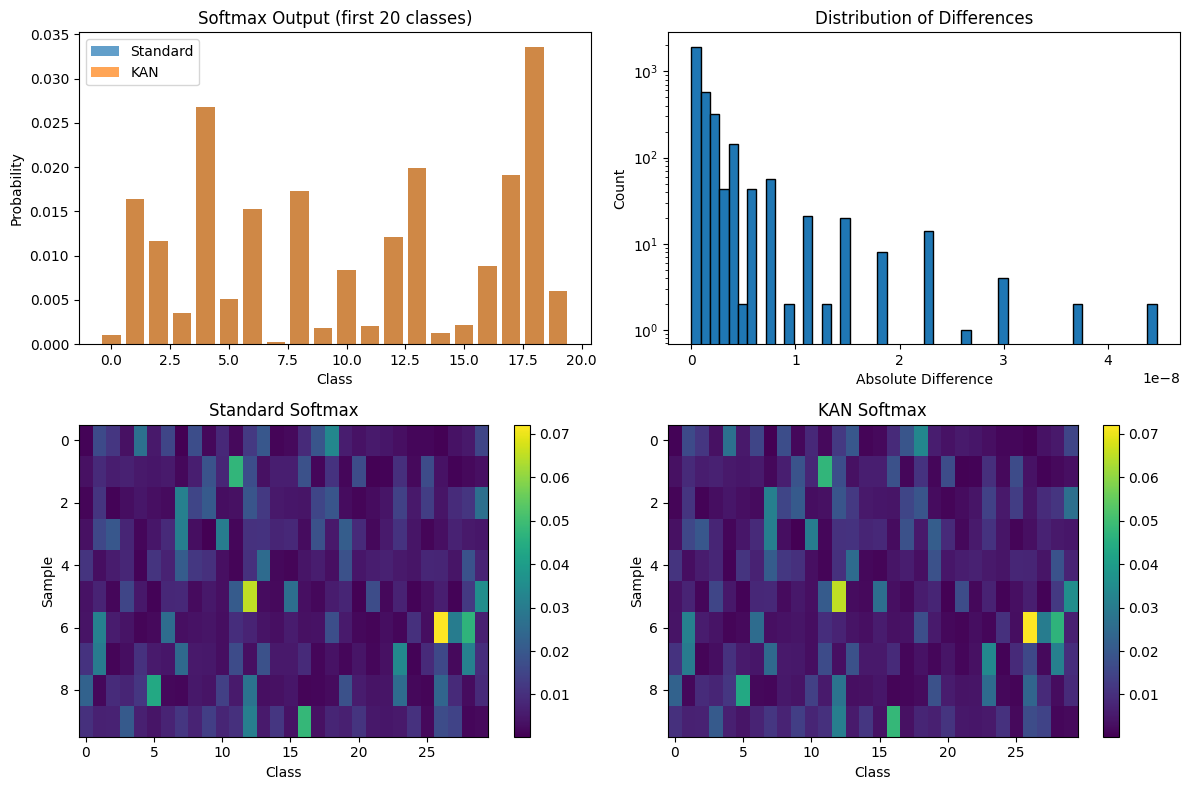

In [7]:
# Visualize softmax outputs
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Single sample comparison
sample_idx = 0
axes[0, 0].bar(range(20), result_std[sample_idx, :20].numpy(), alpha=0.7, label='Standard')
axes[0, 0].bar(range(20), result_kan[sample_idx, :20].numpy(), alpha=0.7, label='KAN')
axes[0, 0].set_title('Softmax Output (first 20 classes)')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Probability')
axes[0, 0].legend()

# Difference histogram
axes[0, 1].hist(diff.flatten().numpy(), bins=50, edgecolor='black')
axes[0, 1].set_title('Distribution of Differences')
axes[0, 1].set_xlabel('Absolute Difference')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_yscale('log')

# Heatmap comparison
im0 = axes[1, 0].imshow(result_std[:10, :30].numpy(), cmap='viridis', aspect='auto')
axes[1, 0].set_title('Standard Softmax')
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('Sample')
plt.colorbar(im0, ax=axes[1, 0])

im1 = axes[1, 1].imshow(result_kan[:10, :30].numpy(), cmap='viridis', aspect='auto')
axes[1, 1].set_title('KAN Softmax')
axes[1, 1].set_xlabel('Class')
axes[1, 1].set_ylabel('Sample')
plt.colorbar(im1, ax=axes[1, 1])

plt.tight_layout()
plt.show()

## 4. Matrix Multiplication: `kan_matmul` vs `@`

In [8]:
# Test matrix multiplication
A = torch.randn(16, 32)  # (M, K)
B = torch.randn(32, 24)  # (K, N)

# Standard matmul
result_std = A @ B

# KAN matmul
result_kan = kan_matmul(A, B)

# Compare
diff = (result_std - result_kan).abs()
print(f"Matrix Multiplication Comparison:")
print(f"  Shape: {A.shape} @ {B.shape} = {result_std.shape}")
print(f"  Max difference: {diff.max().item():.2e}")
print(f"  Mean difference: {diff.mean().item():.2e}")
print(f"  Numerically equal: {torch.allclose(result_std, result_kan, atol=1e-5)}")

Matrix Multiplication Comparison:
  Shape: torch.Size([16, 32]) @ torch.Size([32, 24]) = torch.Size([16, 24])
  Max difference: 5.72e-06
  Mean difference: 6.17e-07
  Numerically equal: True


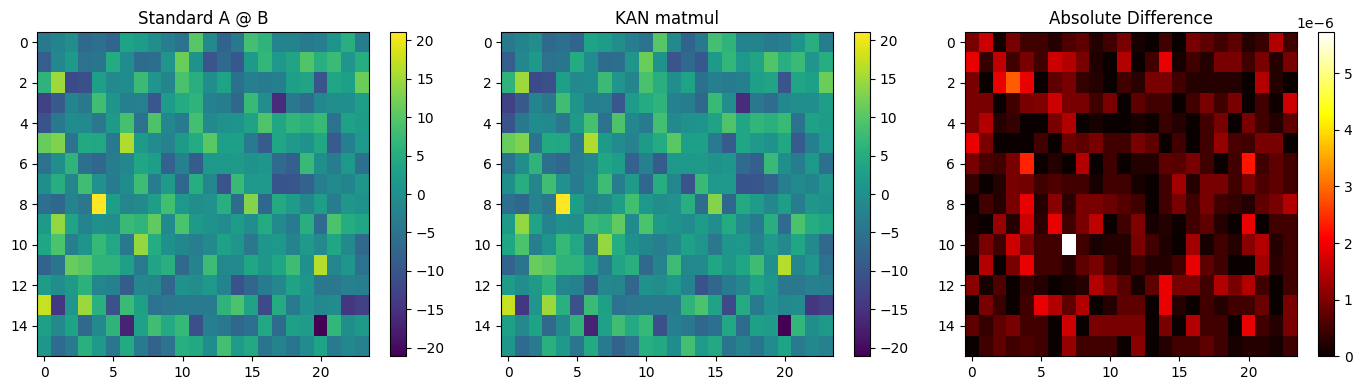

In [9]:
# Visualize matmul
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(result_std.numpy(), cmap='viridis', aspect='auto')
axes[0].set_title('Standard A @ B')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(result_kan.numpy(), cmap='viridis', aspect='auto')
axes[1].set_title('KAN matmul')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(diff.numpy(), cmap='hot', aspect='auto')
axes[2].set_title('Absolute Difference')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## 5. Attention: `AttentionKAN` vs `nn.MultiheadAttention`

In [10]:
# Setup attention layers
embed_dim = 64
num_heads = 4
seq_len = 16
batch_size = 2

# Create layers
attn_kan = AttentionKAN(embed_dim, num_heads, dropout=0.0)
attn_std = nn.MultiheadAttention(embed_dim, num_heads, dropout=0.0, batch_first=True)

# Copy weights from KAN to standard for fair comparison
with torch.no_grad():
    # MultiheadAttention uses combined in_proj_weight
    attn_std.in_proj_weight.copy_(torch.cat([
        attn_kan.q_proj.weight,
        attn_kan.k_proj.weight,
        attn_kan.v_proj.weight
    ], dim=0))
    attn_std.in_proj_bias.copy_(torch.cat([
        attn_kan.q_proj.bias,
        attn_kan.k_proj.bias,
        attn_kan.v_proj.bias
    ], dim=0))
    attn_std.out_proj.weight.copy_(attn_kan.out_proj.weight)
    attn_std.out_proj.bias.copy_(attn_kan.out_proj.bias)

print(f"Attention Setup:")
print(f"  Embed dim: {embed_dim}")
print(f"  Num heads: {num_heads}")
print(f"  Head dim: {embed_dim // num_heads}")
print(f"  Sequence length: {seq_len}")
print(f"  Batch size: {batch_size}")

Attention Setup:
  Embed dim: 64
  Num heads: 4
  Head dim: 16
  Sequence length: 16
  Batch size: 2


In [11]:
# Test attention
x = torch.randn(batch_size, seq_len, embed_dim)

# Eval mode to disable dropout
attn_kan.eval()
attn_std.eval()

with torch.no_grad():
    # KAN attention
    result_kan = attn_kan(x, x, x)
    
    # Standard attention
    result_std, _ = attn_std(x, x, x)

# Compare
diff = (result_std - result_kan).abs()
print(f"Attention Comparison:")
print(f"  Output shape: {result_kan.shape}")
print(f"  Max difference: {diff.max().item():.2e}")
print(f"  Mean difference: {diff.mean().item():.2e}")
print(f"  Numerically equal (atol=1e-4): {torch.allclose(result_std, result_kan, atol=1e-4)}")

Attention Comparison:
  Output shape: torch.Size([2, 16, 64])
  Max difference: 3.43e-07
  Mean difference: 7.42e-08
  Numerically equal (atol=1e-4): True


### FLOPs/Op-Counts (AttentionKAN vs. nn.MultiheadAttention)

In [12]:
class _AttnWrapper(nn.Module):
    def __init__(self, attn):
        super().__init__()
        self.attn = attn

    def forward(self, x):
        if isinstance(self.attn, nn.MultiheadAttention):
            out, _ = self.attn(x, x, x, need_weights=False)
            return out
        return self.attn(x, x, x)

def _print_counts(label, counts):
    total = counts["total"]
    print(label)
    print(f"  total_arith: {total['total_arith']}")
    for key in ("adds", "muls", "divs", "exp", "pow", "relu", "reciprocal", "sqrt", "max", "compare", "subs"): 
        val = total.get(key, 0)
        if val:
            print(f"  {key}: {val}")

wrapper_kan = _AttnWrapper(attn_kan).to(device).eval()
wrapper_std = _AttnWrapper(attn_std).to(device).eval()

input_shape = (batch_size, seq_len, embed_dim)
counts_kan = count_ops(wrapper_kan, input_shape, device=device, per_layer=False)
counts_std = count_ops(wrapper_std, input_shape, device=device, per_layer=False)

_print_counts("AttentionKAN counts:", counts_kan)
_print_counts("MultiheadAttention counts:", counts_std)


AttentionKAN counts:
  total_arith: 4147200
  adds: 1179648
  muls: 593920
  exp: 2048
  pow: 1183744
  reciprocal: 128
  compare: 1920
  subs: 1185792
MultiheadAttention counts:
  total_arith: 1183616
  adds: 587648
  muls: 589824
  divs: 4096
  exp: 2048


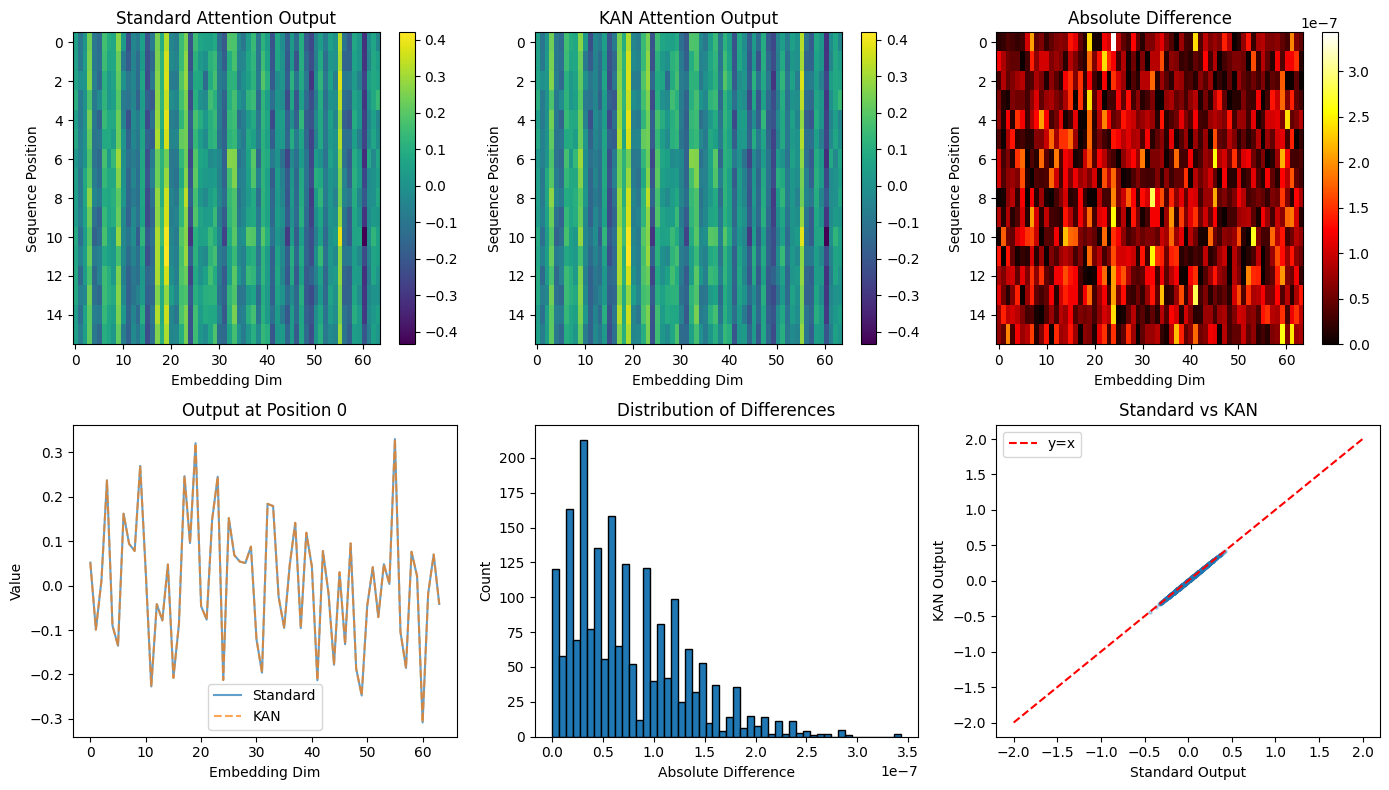

In [13]:
# Visualize attention outputs
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# First batch item
for i, (title, result) in enumerate([('Standard', result_std), ('KAN', result_kan)]):
    im = axes[0, i].imshow(result[0].numpy(), cmap='viridis', aspect='auto')
    axes[0, i].set_title(f'{title} Attention Output')
    axes[0, i].set_xlabel('Embedding Dim')
    axes[0, i].set_ylabel('Sequence Position')
    plt.colorbar(im, ax=axes[0, i])

# Difference
im = axes[0, 2].imshow(diff[0].numpy(), cmap='hot', aspect='auto')
axes[0, 2].set_title('Absolute Difference')
axes[0, 2].set_xlabel('Embedding Dim')
axes[0, 2].set_ylabel('Sequence Position')
plt.colorbar(im, ax=axes[0, 2])

# Single position comparison
pos = 0
axes[1, 0].plot(result_std[0, pos].numpy(), label='Standard', alpha=0.7)
axes[1, 0].plot(result_kan[0, pos].numpy(), label='KAN', alpha=0.7, linestyle='--')
axes[1, 0].set_title(f'Output at Position {pos}')
axes[1, 0].set_xlabel('Embedding Dim')
axes[1, 0].set_ylabel('Value')
axes[1, 0].legend()

# Difference histogram
axes[1, 1].hist(diff.flatten().numpy(), bins=50, edgecolor='black')
axes[1, 1].set_title('Distribution of Differences')
axes[1, 1].set_xlabel('Absolute Difference')
axes[1, 1].set_ylabel('Count')

# Scatter plot
axes[1, 2].scatter(result_std.flatten().numpy(), result_kan.flatten().numpy(), alpha=0.3, s=5)
axes[1, 2].plot([-2, 2], [-2, 2], 'r--', label='y=x')
axes[1, 2].set_title('Standard vs KAN')
axes[1, 2].set_xlabel('Standard Output')
axes[1, 2].set_ylabel('KAN Output')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

## 6. Ops Counter (per-layer, ohne Netz)

In [ ]:
from collections import defaultdict
import re

OP_KEYS = (
    "total_arith",
    "adds",
    "subs",
    "muls",
    "divs",
    "pow",
    "exp",
    "relu",
    "reciprocal",
    "sqrt",
    "max",
    "compare",
)

def _counts_summary(d):
    parts = [f"total_arith={d.get('total_arith', 0)}"]
    for k in OP_KEYS[1:]:
        v = d.get(k, 0)
        if v:
            parts.append(f"{k}={v}")
    return ", ".join(parts)

def _stage_sort_key(stage_path: str):
    if not stage_path:
        return (0, 0, "")
    parts = stage_path.split(".")
    last = parts[-1]
    m = re.fullmatch(r"layer(\d+)", last)
    if m:
        return (0, int(m.group(1)), stage_path)
    return (1, 0, stage_path)

def _ends_with_sum(stage_path: str) -> bool:
    # Heuristic: treat explicit SumKAN stages as layer endings,
    # plus a few known composite stages that end in a sum reduction.
    if not stage_path:
        return False
    last = stage_path.split(".")[-1]
    if "sum" in last:
        return True
    if stage_path.endswith("multiply.layer3"):
        return True
    if stage_path.endswith("pairwise_max.layer2"):
        return True
    return False

def _print_per_layer(per_layer: dict, indent: str = "    "):
    # per_layer keys are module paths (from FX nn_module_stack), e.g.
    #   division.multiply.layer1, matmul.sum_k, q_proj.sum_in, ...
    groups = defaultdict(list)
    for full_name, counts in per_layer.items():
        root, _, rest = full_name.partition(".")
        groups[root].append((rest, counts))

    for root in sorted(groups):
        print(f"{indent}{root}:")
        stages = sorted(groups[root], key=lambda x: _stage_sort_key(x[0]))
        layer_idx = 1
        print(f"{indent}  Layer {layer_idx}:")
        for i, (rest, counts) in enumerate(stages):
            stage = rest if rest else "(self)"
            suffix = " [sum]" if _ends_with_sum(rest) else ""
            print(f"{indent}    - {stage}{suffix}: {_counts_summary(counts)}")
            if _ends_with_sum(rest) and i != len(stages) - 1:
                layer_idx += 1
                print(f"{indent}  Layer {layer_idx}:")

def compare_layer_ops(name, std_layer, kan_layer, input_shape):
    std_counts = count_ops(std_layer, input_shape, per_layer=True)
    print(f"{name}:")
    print("  Non-KAN total:", _counts_summary(std_counts["total"]))
    print("  Non-KAN per-layer:")
    _print_per_layer(std_counts.get("per_layer", {}))
    try:
        kan_counts = count_ops(kan_layer, input_shape, per_layer=True)
        print("  KAN total:", _counts_summary(kan_counts["total"]))
        print("  KAN per-layer (staged):")
        _print_per_layer(kan_counts.get("per_layer", {}))
    except Exception as exc:
        print("  KAN: nicht per fx tracebar:", exc)
    print("")

# Linear
compare_layer_ops(
    "Linear",
    nn.Linear(128, 64),
    LinearKAN(128, 64),
    (1, 128),
)
# Conv2d
compare_layer_ops(
    "Conv2d",
    nn.Conv2d(3, 8, kernel_size=3, padding=1),
    Conv2dKAN(3, 8, kernel_size=3, padding=1),
    (1, 3, 32, 32),
)

# AvgPool2d
compare_layer_ops(
    "AvgPool2d",
    nn.AvgPool2d(kernel_size=2, stride=2),
    AvgPool2dKAN(kernel_size=2, stride=2),
    (1, 8, 32, 32),
)

# MaxPool2d
compare_layer_ops(
    "MaxPool2d",
    nn.MaxPool2d(kernel_size=2, stride=2),
    ReLUMaxPool2dKAN(kernel_size=2, stride=2),
    (1, 8, 32, 32),
)

# Softmax
compare_layer_ops(
    "Softmax",
    nn.Softmax(dim=-1),
    SoftmaxKAN(dim=-1),
    (1, 100),
)


Linear:
  Non-KAN total: {'adds': 8192, 'subs': 0, 'muls': 8192, 'divs': 0, 'pow': 0, 'exp': 0, 'relu': 0, 'reciprocal': 0, 'sqrt': 0, 'max': 0, 'compare': 0, 'total_arith': 16384}
  Non-KAN per-layer: {'inner': {'adds': 8192, 'subs': 0, 'muls': 8192, 'divs': 0, 'pow': 0, 'exp': 0, 'relu': 0, 'reciprocal': 0, 'sqrt': 0, 'max': 0, 'compare': 0, 'total_arith': 16384}}
  KAN total: {'adds': 16384, 'subs': 16384, 'muls': 8192, 'divs': 0, 'pow': 16384, 'exp': 0, 'relu': 0, 'reciprocal': 0, 'sqrt': 0, 'max': 0, 'compare': 0, 'total_arith': 57344}
  KAN per-layer: {'inner': {'adds': 16384, 'subs': 16384, 'muls': 8192, 'divs': 0, 'pow': 16384, 'exp': 0, 'relu': 0, 'reciprocal': 0, 'sqrt': 0, 'max': 0, 'compare': 0, 'total_arith': 57344}}

Conv2d:
  Non-KAN total: {'adds': 221184, 'subs': 0, 'muls': 221184, 'divs': 0, 'pow': 0, 'exp': 0, 'relu': 0, 'reciprocal': 0, 'sqrt': 0, 'max': 0, 'compare': 0, 'total_arith': 442368}
  Non-KAN per-layer: {'inner': {'adds': 221184, 'subs': 0, 'muls': 221184

## 7. Performance Comparison

In [15]:
def benchmark(fn, *args, n_runs=100, warmup=10):
    """Benchmark a function."""
    # Warmup
    for _ in range(warmup):
        fn(*args)
    
    # Benchmark
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    start = time.perf_counter()
    for _ in range(n_runs):
        fn(*args)
    
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    end = time.perf_counter()
    return (end - start) / n_runs * 1000  # ms

In [16]:
# Benchmark multiplication
sizes = [32, 64, 128, 256, 512]
mul_std_times = []
mul_kan_times = []

for size in sizes:
    a = torch.randn(size, size)
    b = torch.randn(size, size)
    
    mul_std_times.append(benchmark(lambda: a * b))
    mul_kan_times.append(benchmark(lambda: kan_multiply(a, b)))

print("Multiplication Benchmark (ms):")
print(f"{'Size':<10} {'Standard':<15} {'KAN':<15} {'Ratio':<10}")
print("-" * 50)
for i, size in enumerate(sizes):
    ratio = mul_kan_times[i] / mul_std_times[i]
    print(f"{size:<10} {mul_std_times[i]:<15.4f} {mul_kan_times[i]:<15.4f} {ratio:<10.2f}x")

Multiplication Benchmark (ms):
Size       Standard        KAN             Ratio     
--------------------------------------------------
32         0.0026          0.0221          8.43      x
64         0.0031          0.0340          10.93     x
128        0.0056          0.0534          9.55      x
256        0.0110          0.0911          8.31      x
512        0.0231          1.4291          61.86     x


In [17]:
# Benchmark softmax
softmax_std_times = []
softmax_kan_times = []
softmax_kan = SoftmaxKAN(dim=-1)

for size in sizes:
    x = torch.randn(32, size)
    
    softmax_std_times.append(benchmark(lambda: F.softmax(x, dim=-1)))
    softmax_kan_times.append(benchmark(lambda: softmax_kan(x)))

print("\nSoftmax Benchmark (ms):")
print(f"{'Size':<10} {'Standard':<15} {'KAN':<15} {'Ratio':<10}")
print("-" * 50)
for i, size in enumerate(sizes):
    ratio = softmax_kan_times[i] / softmax_std_times[i]
    print(f"{size:<10} {softmax_std_times[i]:<15.4f} {softmax_kan_times[i]:<15.4f} {ratio:<10.2f}x")


Softmax Benchmark (ms):
Size       Standard        KAN             Ratio     
--------------------------------------------------
32         0.0073          0.1829          24.99     x
64         0.0033          0.1935          57.90     x
128        0.0051          0.2278          44.32     x
256        0.0053          0.2875          54.49     x
512        0.0081          0.3359          41.59     x


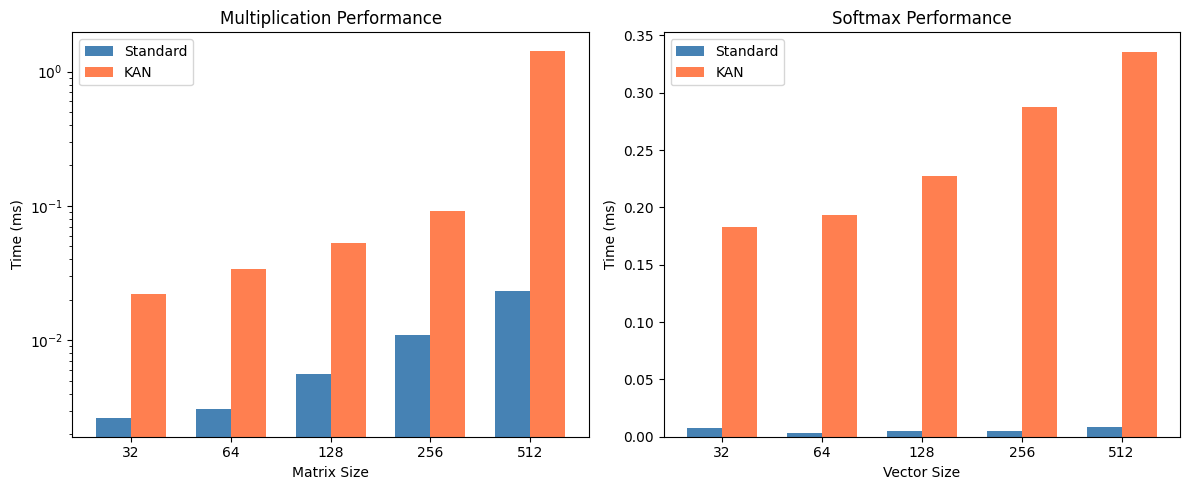

In [18]:
# Visualize performance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Multiplication
x_pos = np.arange(len(sizes))
width = 0.35

axes[0].bar(x_pos - width/2, mul_std_times, width, label='Standard', color='steelblue')
axes[0].bar(x_pos + width/2, mul_kan_times, width, label='KAN', color='coral')
axes[0].set_xlabel('Matrix Size')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Multiplication Performance')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(sizes)
axes[0].legend()
axes[0].set_yscale('log')

# Softmax
axes[1].bar(x_pos - width/2, softmax_std_times, width, label='Standard', color='steelblue')
axes[1].bar(x_pos + width/2, softmax_kan_times, width, label='KAN', color='coral')
axes[1].set_xlabel('Vector Size')
axes[1].set_ylabel('Time (ms)')
axes[1].set_title('Softmax Performance')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(sizes)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Benchmark (std vs KAN) for all layers
# Note: KAN versions are much slower; keep sizes modest.

from collections import OrderedDict

N_RUNS = 200 if device.type == "cuda" else 50
WARMUP = 30 if device.type == "cuda" else 10

def _bench_ms(fn):
    return benchmark(fn, n_runs=N_RUNS, warmup=WARMUP)

def _print_table(title, sizes, std_ms, kan_ms):
    print(f"\n{title} (ms)  [runs={N_RUNS}, warmup={WARMUP}, device={device}]")
    print(f"{'Size':<10} {'Standard':<15} {'KAN':<15} {'Ratio':<10}")
    print("-" * 55)
    for s, t0, t1 in zip(sizes, std_ms, kan_ms):
        ratio = (t1 / t0) if t0 else float('inf')
        print(f"{s!s:<10} {t0:<15.4f} {t1:<15.4f} {ratio:<10.2f}x")

bench_all = OrderedDict()

# 1) Multiplication: a*b vs kan_multiply(a,b)
sizes_mul = [16, 32, 64, 128]
mul_std, mul_kan = [], []
for n in sizes_mul:
    a = torch.randn(n, n, device=device)
    b = torch.randn(n, n, device=device)
    with torch.no_grad():
        mul_std.append(_bench_ms(lambda: a * b))
        mul_kan.append(_bench_ms(lambda: kan_multiply(a, b)))
bench_all["Multiplication"] = (sizes_mul, mul_std, mul_kan)

# 2) Division: a/b vs DivisionKAN(a,b)
sizes_div = [128, 256, 512, 1024]
div_std, div_kan = [], []
div_kan_layer = DivisionKAN(eps=1e-8).to(device).eval()
for n in sizes_div:
    a = torch.randn(64, n, device=device)
    b = torch.rand(64, n, device=device) + 1e-3  # avoid zeros
    with torch.no_grad():
        div_std.append(_bench_ms(lambda: a / b))
        div_kan.append(_bench_ms(lambda: div_kan_layer(a, b)))
bench_all["Division"] = (sizes_div, div_std, div_kan)

# 3) Linear: nn.Linear vs LinearKAN (weights copied for fairness)
sizes_linear = [128, 256, 512, 1024]
lin_std, lin_kan = [], []
for n in sizes_linear:
    std = nn.Linear(n, n, bias=True).to(device).eval()
    kan = LinearKAN(n, n, bias=True).to(device).eval()
    with torch.no_grad():
        std.weight.copy_(kan.weight)
        if std.bias is not None and kan.bias is not None:
            std.bias.copy_(kan.bias)
    x = torch.randn(64, n, device=device)
    with torch.no_grad():
        lin_std.append(_bench_ms(lambda: std(x)))
        lin_kan.append(_bench_ms(lambda: kan(x)))
bench_all["Linear"] = (sizes_linear, lin_std, lin_kan)

# 4) Conv2d: nn.Conv2d vs Conv2dKAN (weights copied)
sizes_conv = [16, 32, 64]
conv_std, conv_kan = [], []
for s in sizes_conv:
    std = nn.Conv2d(3, 8, kernel_size=3, padding=1, bias=True).to(device).eval()
    kan = Conv2dKAN(3, 8, kernel_size=3, padding=1, bias=True).to(device).eval()
    with torch.no_grad():
        std.weight.copy_(kan.weight)
        if std.bias is not None and kan.bias is not None:
            std.bias.copy_(kan.bias)
    x = torch.randn(4, 3, s, s, device=device)
    with torch.no_grad():
        conv_std.append(_bench_ms(lambda: std(x)))
        conv_kan.append(_bench_ms(lambda: kan(x)))
bench_all["Conv2d"] = (sizes_conv, conv_std, conv_kan)

# 5) AvgPool2d: nn.AvgPool2d vs AvgPool2dKAN
sizes_pool = [32, 64, 128]
avg_std, avg_kan = [], []
for s in sizes_pool:
    std = nn.AvgPool2d(kernel_size=2, stride=2).to(device).eval()
    kan = AvgPool2dKAN(kernel_size=2, stride=2).to(device).eval()
    x = torch.randn(4, 8, s, s, device=device)
    with torch.no_grad():
        avg_std.append(_bench_ms(lambda: std(x)))
        avg_kan.append(_bench_ms(lambda: kan(x)))
bench_all["AvgPool2d"] = (sizes_pool, avg_std, avg_kan)

# 6) MaxPool2d: nn.MaxPool2d vs ReLUMaxPool2dKAN
max_std, max_kan = [], []
for s in sizes_pool:
    std = nn.MaxPool2d(kernel_size=2, stride=2).to(device).eval()
    kan = ReLUMaxPool2dKAN(kernel_size=2, stride=2).to(device).eval()
    x = torch.randn(4, 8, s, s, device=device)
    with torch.no_grad():
        max_std.append(_bench_ms(lambda: std(x)))
        max_kan.append(_bench_ms(lambda: kan(x)))
bench_all["MaxPool2d"] = (sizes_pool, max_std, max_kan)

# 7) Softmax: F.softmax vs SoftmaxKAN
sizes_soft = [128, 256, 512, 1024]
sm_std, sm_kan = [], []
sm_kan_layer = SoftmaxKAN(dim=-1, stable=True, eps=1e-8).to(device).eval()
for n in sizes_soft:
    x = torch.randn(64, n, device=device)
    with torch.no_grad():
        sm_std.append(_bench_ms(lambda: F.softmax(x, dim=-1)))
        sm_kan.append(_bench_ms(lambda: sm_kan_layer(x)))
bench_all["Softmax"] = (sizes_soft, sm_std, sm_kan)

# 8) MatMul: A@B vs MatMulKAN(A,B)
sizes_mm = [16, 32, 64, 128]
mm_std, mm_kan = [], []
mm_kan_layer = (lambda: None)
from converted_KAN.attentionkan import MatMulKAN
mm_kan_layer = MatMulKAN().to(device).eval()
for n in sizes_mm:
    a = torch.randn(8, n, n, device=device)
    b = torch.randn(8, n, n, device=device)
    with torch.no_grad():
        mm_std.append(_bench_ms(lambda: a @ b))
        mm_kan.append(_bench_ms(lambda: mm_kan_layer(a, b)))
bench_all["MatMul"] = (sizes_mm, mm_std, mm_kan)

# 9) Attention: nn.MultiheadAttention vs AttentionKAN (weights copied)
seq_lens = [8, 16, 32]
att_std, att_kan = [], []
embed_dim = 64
num_heads = 4
attn_kan_b = AttentionKAN(embed_dim, num_heads, dropout=0.0).to(device).eval()
attn_std_b = nn.MultiheadAttention(embed_dim, num_heads, dropout=0.0, batch_first=True).to(device).eval()
with torch.no_grad():
    attn_std_b.in_proj_weight.copy_(torch.cat([
        attn_kan_b.q_proj.weight,
        attn_kan_b.k_proj.weight,
        attn_kan_b.v_proj.weight
    ], dim=0))
    attn_std_b.in_proj_bias.copy_(torch.cat([
        attn_kan_b.q_proj.bias,
        attn_kan_b.k_proj.bias,
        attn_kan_b.v_proj.bias
    ], dim=0))
    attn_std_b.out_proj.weight.copy_(attn_kan_b.out_proj.weight)
    attn_std_b.out_proj.bias.copy_(attn_kan_b.out_proj.bias)

for s in seq_lens:
    x = torch.randn(2, s, embed_dim, device=device)
    with torch.no_grad():
        att_std.append(_bench_ms(lambda: attn_std_b(x, x, x, need_weights=False)[0]))
        att_kan.append(_bench_ms(lambda: attn_kan_b(x, x, x)))
bench_all["Attention"] = (seq_lens, att_std, att_kan)

for name, (sizes, std_ms, kan_ms) in bench_all.items():
    _print_table(name, sizes, std_ms, kan_ms)


## 8. Summary

In [19]:
print("=" * 60)
print("SUMMARY: KAN vs Standard Layers")
print("=" * 60)
print()
print("Numerical Accuracy:")
print("  - All KAN implementations are numerically equivalent")
print("  - Small differences due to floating-point arithmetic")
print()
print("KAN Operations (only additions + unary functions):")
print("  - Multiplication: 4ab = (a+b)² - (a-b)²")
print("  - Division: a/b = a × (1/b) with reciprocal")
print("  - Softmax: exp(x) / Σexp(x) via KAN division")
print("  - Attention: Q@K^T via KAN matmul, then softmax, then @V")
print()
print("Performance:")
print("  - KAN operations are slower (more operations)")
print("  - But: Mathematically equivalent to standard ops")
print("  - Theoretical value: Shows that all NNs can be expressed as KANs")

SUMMARY: KAN vs Standard Layers

Numerical Accuracy:
  - All KAN implementations are numerically equivalent
  - Small differences due to floating-point arithmetic

KAN Operations (only additions + unary functions):
  - Multiplication: 4ab = (a+b)² - (a-b)²
  - Division: a/b = a × (1/b) with reciprocal
  - Softmax: exp(x) / Σexp(x) via KAN division
  - Attention: Q@K^T via KAN matmul, then softmax, then @V

Performance:
  - KAN operations are slower (more operations)
  - But: Mathematically equivalent to standard ops
  - Theoretical value: Shows that all NNs can be expressed as KANs
